[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YangKCLab/social-media-analysis/blob/main/docs/topics/network/networkx-basics.ipynb)

# NetworkX basics

A network has nodes, and edges that connect the nodes.
This notebook creates a small network with NetworkX, loads a network from a file, and measures it: the degrees, the shortest paths, the degree distribution, and the friendship paradox.
It uses a network with four nodes, Zachary's karate club network, and the follower counts of 698 Twitter accounts.

Sections: Create a network, Network methods, Node degrees, Edge list and adjacency matrix, Load the karate club network, Paths and distances, Degree distribution of a real network, Friendship paradox.

Packages beyond the standard library: `networkx`, `numpy`, `pandas`, `matplotlib`.
Install them with `uv add networkx numpy pandas matplotlib` (or `pip install`).
Colab already has all four.

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

# Figure settings: a larger font, and tick marks drawn behind the data.
plt.rcParams.update({"font.size": 14, "axes.axisbelow": True})

## Create a network

NetworkX calls a network a graph.
`nx.Graph()` creates an empty undirected network.
A node can have any name that Python can use as a dictionary key, for example a string or a number.

In [2]:
# A "plain" graph is undirected
G = nx.Graph()

# Give each node a name, which is a letter here
G.add_node("a")

# Add several nodes from a list
G.add_nodes_from(["b", "c", "d"])

# Add an edge from "a" to "b"
# The graph is undirected, so the order does not matter
G.add_edge("a", "b")

# Add several edges from a list of 2-tuples
G.add_edges_from([("a", "c"), ("b", "c"), ("c", "d")])

The network now has four nodes and four edges.
`nx.draw` draws it.

Without the argument `pos`, `nx.draw` chooses the positions of the nodes at random, so each run gives a different picture.
`nx.spring_layout(G, seed=415)` computes the positions with a fixed seed, so each run gives the same picture.

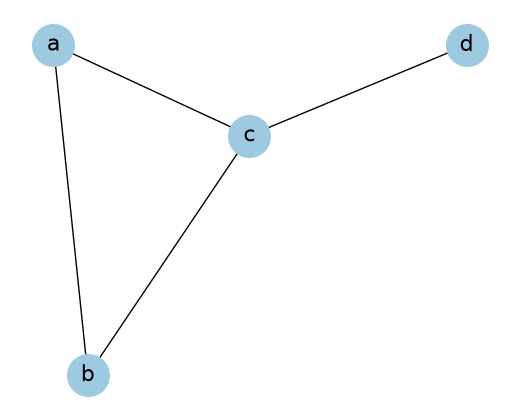

In [3]:
plt.figure(figsize=(5, 4))
nx.draw(
    G,
    pos=nx.spring_layout(G, seed=415),
    with_labels=True,
    node_color="#9ecae1",
    node_size=900,
    font_size=16,
)
plt.show()

The nodes `a`, `b`, and `c` form a triangle.
The node `d` is connected only to `c`.

For a directed network, use `nx.DiGraph()` in place of `nx.Graph()`.
In a directed network, `add_edge("a", "b")` adds an edge from `a` to `b`, so the order matters.

## Network methods

`G.nodes()` lists the nodes, and `G.edges()` lists the edges.

In [4]:
G.nodes()

NodeView(('a', 'b', 'c', 'd'))

The call returns `NodeView(('a', 'b', 'c', 'd'))`.

In [5]:
G.edges()

EdgeView([('a', 'b'), ('a', 'c'), ('b', 'c'), ('c', 'd')])

The call returns `EdgeView([('a', 'b'), ('a', 'c'), ('b', 'c'), ('c', 'd')])`.
Each edge is a pair of nodes.

The next cell counts the nodes and the edges.

In [6]:
print(G.number_of_nodes())
print(G.number_of_edges())

4
4


The network has 4 nodes and 4 edges.

The neighbors of a node are the nodes that share an edge with it.
`G.neighbors` returns an iterator, so the cell needs `list` to show the neighbors.

In [7]:
# The neighbors of the node "b"
list(G.neighbors("b"))

['a', 'c']

The neighbors of `b` are `['a', 'c']`.
You can also loop over the neighbors.

In [8]:
for node in G.neighbors("b"):
    print(node)

a
c


The loop prints `a` and `c`.

## Node degrees

The degree of a node is the number of edges that it has.
In an undirected network, this is also the number of its neighbors.

In [9]:
# Count the neighbors of a node
len(list(G.neighbors("a")))

2

In [10]:
# Or, use G.degree
G.degree("a")

2

Both cells return 2.

A node of a directed network has two degrees.
The in-degree is the number of edges that point to the node.
The out-degree is the number of edges that point from the node.
A network made with `nx.DiGraph()` has `G.in_degree` and `G.out_degree` for them.
Take a follower network with an edge from each follower to the account that it follows.
There the in-degree of an account is its number of followers.

`G.degree()` without an argument gives the degree of every node, as pairs of a node and its degree.
The next cell puts the degrees in a pandas Series.

In [11]:
degree_sequence = pd.Series([d for _, d in G.degree()])
degree_sequence.tolist()

[2, 2, 3, 1]

The degrees are `[2, 2, 3, 1]`, in the order of the nodes `a`, `b`, `c`, and `d`.

The degree distribution of a network is the share of the nodes that have each degree.
A histogram of the degrees shows it.

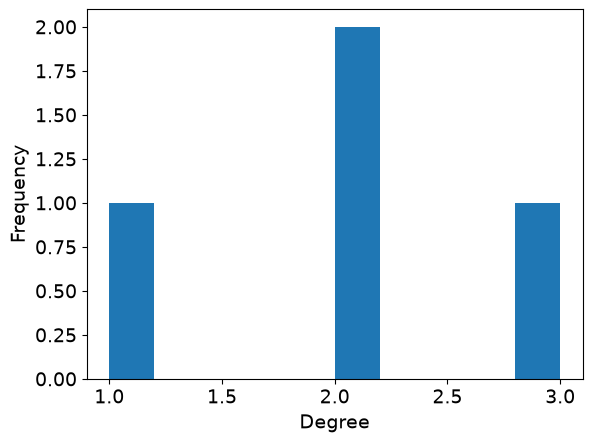

In [12]:
plt.hist(degree_sequence)
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

One node has degree 1, two nodes have degree 2, and one node has degree 3.

## Edge list and adjacency matrix

There are two common ways to write down a network.

An edge list has one row for each edge.
`nx.to_pandas_edgelist` returns the edge list of a network as a table.

In [13]:
nx.to_pandas_edgelist(G)

,source,target
0,a,b
1,a,c
2,b,c
3,c,d


The table has one row for each of the four edges:

| source | target |
| --- | --- |
| a | b |
| a | c |
| b | c |
| c | d |

You can store an edge list as a CSV file.
The file does not say if the network is directed, so you must state it.

An adjacency matrix has one row and one column for each node.
The entry in row i and column j is 1 if an edge connects node i and node j, and 0 otherwise.
`nx.to_numpy_array` returns the adjacency matrix.
The rows and the columns are in the order of `G.nodes()`.

In [14]:
nx.to_numpy_array(G)

array([[0., 1., 1., 0.],
       [1., 0., 1., 0.],
       [1., 1., 0., 1.],
       [0., 0., 1., 0.]])

The call returns this matrix:

```text
array([[0., 1., 1., 0.],
       [1., 0., 1., 0.],
       [1., 1., 0., 1.],
       [0., 0., 1., 0.]])
```

The first row is the node `a`, which is connected to `b` and `c`.
The matrix of an undirected network is symmetric.
The sum of a row is the degree of the node.

## Load the karate club network

Most networks come from a file.
This section loads an edge list file.

The data is Zachary's karate club network: the social ties among the 34 members of a
university karate club ([Zachary, 1977](https://doi.org/10.1086/jar.33.4.3629752)). The file
is an edge list. Each line has the numbers of two members who are connected.

In [15]:
import pathlib
import urllib.request

import networkx as nx

# The file is not in the site repository. This cell downloads it once from the
# public course repository, at a fixed commit.
url = (
    "https://raw.githubusercontent.com/YangKCLab/social-media-ds-course/"
    "cb145f40a693e111025273947d0e430d7d325a33/demos/network/karate.edgelist"
)
path = pathlib.Path("data") / "karate.edgelist"
path.parent.mkdir(exist_ok=True)
if not path.exists():
    urllib.request.urlretrieve(url, path)

karate_g = nx.read_edgelist(path)
karate_g.number_of_nodes()    # 34
karate_g.number_of_edges()    # 78

78

The cell downloads the file (407 bytes) into `data/` next to this notebook, unless the file is already there.
`nx.read_edgelist` reads the file and returns an undirected network.
The network has 34 nodes and 78 edges.
A notebook shows only the value of the last line of a cell, which is 78 here.

For an edge list in a pandas table, use `nx.from_pandas_edgelist`.

NetworkX reads the node names of an edge list file as strings.

In [16]:
list(karate_g.nodes())[:5]

['2', '1', '3', '4', '5']

The first five nodes are `['2', '1', '3', '4', '5']`.
The node is `"1"`, not `1`.
The first line of the file is `2 1`, so `"2"` is the first node.

Draw the network with a fixed layout.

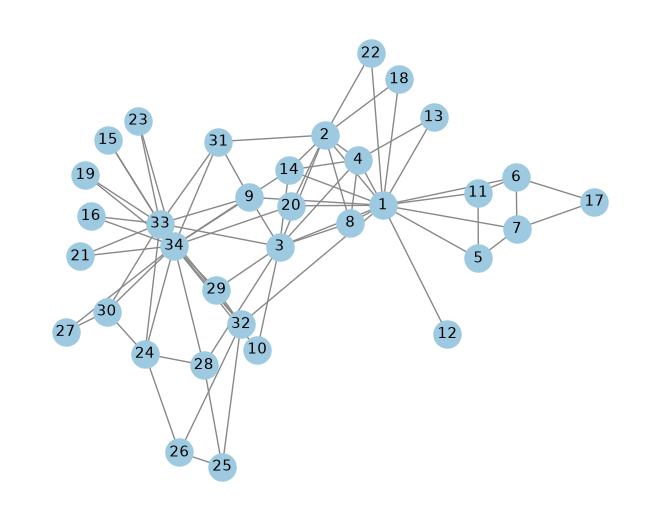

In [17]:
pos = nx.spring_layout(karate_g, seed=415)

plt.figure(figsize=(6.4, 5))
nx.draw(
    karate_g,
    pos=pos,
    with_labels=True,
    node_color="#9ecae1",
    node_size=380,
    font_size=11,
    edge_color="#888888",
)
plt.show()

Each node is one member of the club, and each edge is a social tie between two members.
The nodes `1`, `33`, and `34` have the most edges.

## Paths and distances

A path is a route that runs along the edges of a network.
The length of a path is the number of edges in it.
The distance between two nodes is the length of the shortest path between them.

`nx.shortest_path` returns one shortest path between two nodes.

In [18]:
nx.shortest_path(karate_g, "16", "17")

['16', '33', '3', '1', '6', '17']

The path is `['16', '33', '3', '1', '6', '17']`.
It has six nodes and five edges, so the distance between the two members is 5.
Two nodes can have several shortest paths of the same length, and the function returns one of them.

`nx.shortest_path_length` returns the distance without the path.

In [19]:
nx.shortest_path_length(karate_g, "16", "17")

5

The distance is 5.

`nx.average_shortest_path_length` returns the average distance over all pairs of nodes.

In [20]:
nx.average_shortest_path_length(karate_g)

2.408199643493761

The average distance is 2.41 (the call returns 2.408199643493761).
On average, two members of the club are 2.41 steps apart.

This function raises an error on a network that is not connected, because some pairs of nodes have no path between them.
The notebook "Posts to networks" of this section shows how to find the connected components of a network and how to keep the largest one.

## Degree distribution of a real network

The degrees of a real network are usually highly skewed.
A few nodes have very high degrees, and most nodes have low degrees.
The nodes with very high degrees are called hubs.

The example is the number of followers of 698 Twitter accounts.
The number of followers is the in-degree of an account in the follower network.

The data is Botwiki-2019: 698 Twitter accounts that identified themselves as bots, from the
[Bot Repository](https://botometer.osome.iu.edu/bot-repository/datasets.html)
([Yang et al., 2020](https://doi.org/10.1609/aaai.v34i01.5460)). The dataset has the license
[CC BY-NC-ND 4.0](https://creativecommons.org/licenses/by-nc-nd/4.0/). This notebook uses two
numbers for each account: the number of followers and the number of friends.

In [21]:
import gzip
import json
import pathlib
import urllib.request

import pandas as pd

# The file is not in the site repository. This cell downloads it once from the
# public course repository, at a fixed commit.
url = (
    "https://raw.githubusercontent.com/YangKCLab/social-media-ds-course/"
    "b4a210426ebfec34f2e983983efde03eeb3dba8d/demos/stats/botwiki-2019_tweets.json.gz"
)
path = pathlib.Path("data") / "botwiki-2019_tweets.json.gz"
path.parent.mkdir(exist_ok=True)
if not path.exists():
    urllib.request.urlretrieve(url, path)

with gzip.open(path) as f:
    botwiki = json.load(f)
botwiki_df = pd.DataFrame.from_records([item["user"] for item in botwiki])
botwiki_df = botwiki_df[["followers_count", "friends_count"]]
len(botwiki_df)    # 698

698

The cell downloads the file (154 KB) into `data/` next to this notebook, unless the file is already there.
The table has 698 rows, one for each account.
The cell keeps two fields of each account, `followers_count` and `friends_count`.
This section plots only `followers_count`.

The follower counts differ by orders of magnitude, so a histogram with bins of the same size does not work.
`np.logspace(0, 6.2, num=20)` returns 20 bin edges from 10^0 = 1 to 10^6.2, which is about 1.6 million.
Each bin is about 2.1 times as wide as the bin before it.
`plt.xscale("log")` puts the x-axis in log scale as well.

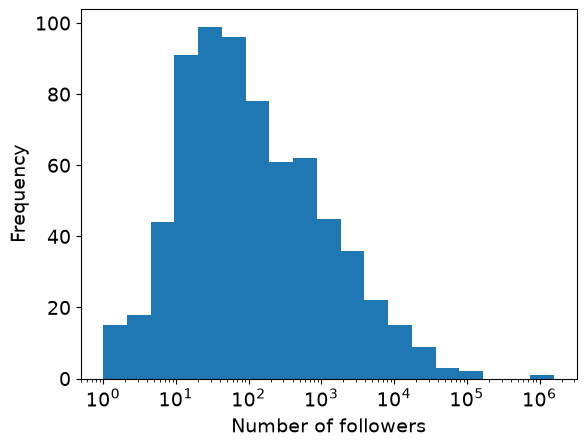

In [22]:
plt.hist(botwiki_df.followers_count, bins=np.logspace(0, 6.2, num=20))
plt.xscale("log")
plt.xlabel("Number of followers")
plt.ylabel("Frequency")
plt.show()

Most accounts have between 10 and 1,000 followers, and a few accounts have far more.
A log axis cannot show 0, so an account with 0 followers is not in the plot.

The mean does not describe such a distribution well.
Report the median, and plot the distribution on a log scale.
A network whose degree distribution follows a power law is called a scale-free network.

## Friendship paradox

On average, the friends of a person have more friends than the person.
This is the friendship paradox.
The reason is that a person with many friends is counted many times as a friend of someone.

In the karate club network, the number of friends of a member is the degree of the node.
The next cell computes the mean degree.

In [23]:
degrees = np.array([d for _, d in karate_g.degree()])

# The mean number of friends
print(round(degrees.mean(), 2))

4.59


A member has 4.59 friends on average.

Now take every friend of every member.
A member with degree k is in this list k times, once for each of the k friends.
So the mean number of friends of a friend is the sum of k * k over all members, divided by the sum of k.

In [24]:
# The mean number of friends of a friend is sum(k^2) / sum(k)
print(round((degrees**2).sum() / degrees.sum(), 2))

7.77


A friend has 7.77 friends on average, which is more than 4.59.
The second mean is larger than the first one whenever the members have different numbers of friends.

The next cell counts the members who have fewer friends than their own friends have on average.
`karate_g[v]` gives the neighbors of the node `v`.

In [25]:
below = sum(
    karate_g.degree(v) < np.mean([karate_g.degree(u) for u in karate_g[v]])
    for v in karate_g
)
print(f"{below} of {karate_g.number_of_nodes()}")

29 of 34


29 of the 34 members have fewer friends than their friends have on average.